Tugas:
Perbandingan metode peningkatan kontras pada citra grayscale berkontras rendah.

Metode yang dibandingkan:
1. Contrast stretching (exposure.rescale_intensity)
2. Histogram equalization (exposure.equalize_hist)

Output yang ditampilkan:
- Citra asli low-contrast
- Citra hasil stretching
- Citra hasil equalization
- Histogram ketiganya

Tujuan:
Menentukan metode yang lebih efektif untuk meningkatkan kontras dan memahami karakter hasil masing-masing metode.

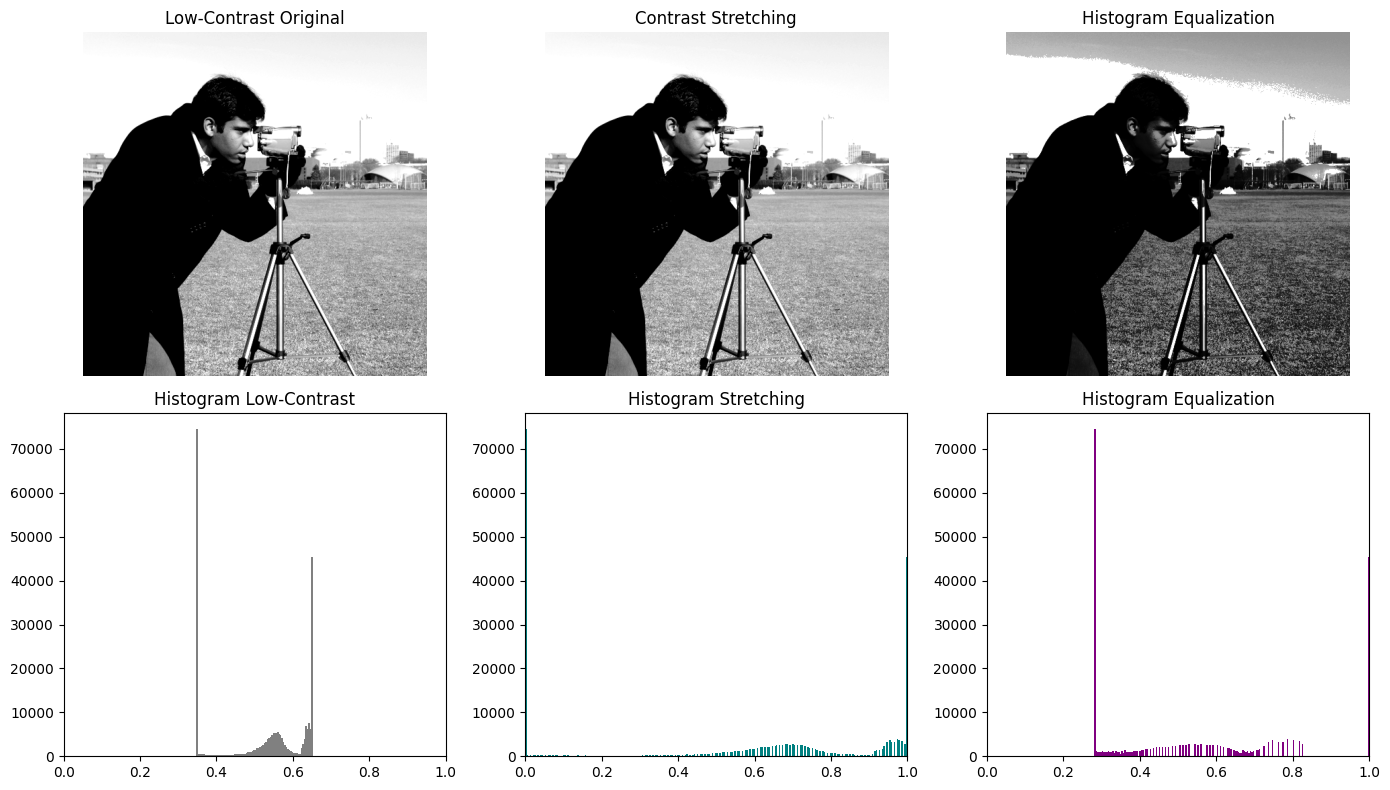

Analisis singkat:
- Contrast stretching memperlebar rentang intensitas secara terkontrol.
- Histogram equalization meratakan distribusi intensitas, kontras lokal sering lebih kuat.
- Efektivitas tergantung karakter citra: stretching biasanya lebih natural, equalization lebih agresif.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# 1) Siapkan citra grayscale lalu buat versi low-contrast
img = img_as_float(data.camera())
img_low = exposure.rescale_intensity(img, in_range=(0.2, 0.8), out_range=(0.35, 0.65))

# 2) Metode 1: Contrast stretching
p2, p98 = np.percentile(img_low, (2, 98))
img_stretch = exposure.rescale_intensity(img_low, in_range=(p2, p98), out_range=(0, 1))

# 3) Metode 2: Histogram equalization
img_eq = exposure.equalize_hist(img_low)

# 4) Visualisasi citra
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0, 0].imshow(img_low, cmap='gray')
axes[0, 0].set_title("Low-Contrast Original")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_stretch, cmap='gray')
axes[0, 1].set_title("Contrast Stretching")
axes[0, 1].axis('off')

axes[0, 2].imshow(img_eq, cmap='gray')
axes[0, 2].set_title("Histogram Equalization")
axes[0, 2].axis('off')

# 5) Visualisasi histogram
axes[1, 0].hist(img_low.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 0].set_title("Histogram Low-Contrast")
axes[1, 0].set_xlim(0, 1)

axes[1, 1].hist(img_stretch.ravel(), bins=256, range=(0, 1), color='teal')
axes[1, 1].set_title("Histogram Stretching")
axes[1, 1].set_xlim(0, 1)

axes[1, 2].hist(img_eq.ravel(), bins=256, range=(0, 1), color='purple')
axes[1, 2].set_title("Histogram Equalization")
axes[1, 2].set_xlim(0, 1)

plt.tight_layout()
plt.show()

print("Analisis singkat:")
print("- Contrast stretching memperlebar rentang intensitas secara terkontrol.")
print("- Histogram equalization meratakan distribusi intensitas, kontras lokal sering lebih kuat.")
print("- Efektivitas tergantung karakter citra: stretching biasanya lebih natural, equalization lebih agresif.")